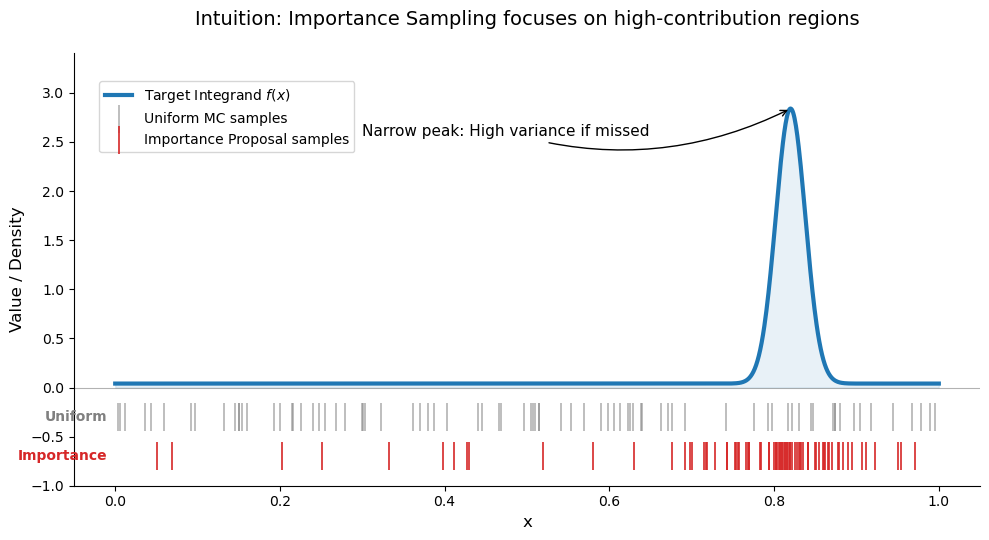

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(7)

# ---------------------------------
# Target "ugly" narrow-peak function on [0,1]
# ---------------------------------
x = np.linspace(0.0, 1.0, 1200)
peak_mu = 0.82
peak_sigma = 0.018

# Target integrand
f = 0.04 + 2.8 * np.exp(-0.5 * ((x - peak_mu) / peak_sigma) ** 2)

# ---------------------------------
# Uniform MC samples
# ---------------------------------
n = 80
x_uni = rng.uniform(0.0, 1.0, n)

# ---------------------------------
# Importance Sampling Proposal
# ---------------------------------
# 75% Gaussian near peak, 25% Uniform
n_gauss = int(n * 0.75)
n_uni = n - n_gauss

# Sample Gaussian (Truncated to [0, 1])
vals = []
while len(vals) < n_gauss:
    cand = rng.normal(loc=peak_mu, scale=0.06, size=n_gauss)
    cand = cand[(cand >= 0.0) & (cand <= 1.0)]
    vals.extend(cand.tolist())
x_gauss_part = np.array(vals[:n_gauss])

# Sample Uniform part
x_uni_part = rng.uniform(0.0, 1.0, n_uni)

# Combine
x_imp = np.concatenate([x_gauss_part, x_uni_part])

# ---------------------------------
# Plot
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 5.5))

# Target curve
ax.plot(x, f, linewidth=3, color='#1f77b4', label="Target Integrand $f(x)$")

# Fill the area under the peak to show "contribution"
ax.fill_between(x, f, alpha=0.1, color='#1f77b4')

# Rug-like sample markers (Uniform)
# Positioned at y = -0.2
ax.scatter(x_uni, np.full_like(x_uni, -0.3), 
           marker="|", s=400, linewidths=1.2, color='gray', alpha=0.6,
           label="Uniform MC samples")

# Rug-like sample markers (Importance)
# Positioned at y = -0.6
ax.scatter(x_imp, np.full_like(x_imp, -0.7), 
           marker="|", s=400, linewidths=1.2, color='#d62728', 
           label="Importance Proposal samples")

# Annotation
ax.annotate(
    "Narrow peak: High variance if missed",
    xy=(peak_mu, f.max()),
    xytext=(0.3, f.max() * 0.9),
    fontsize=11,
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"),
)

# Text labels for the sample rows
ax.text(-0.01, -0.3, "Uniform", ha="right", va="center", fontweight='bold', color='gray')
ax.text(-0.01, -0.7, "Importance", ha="right", va="center", fontweight='bold', color='#d62728')

# Styling
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-1.0, f.max() * 1.2)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("Value / Density", fontsize=12)
ax.set_title("Intuition: Importance Sampling focuses on high-contribution regions", pad=20, fontsize=14)

# Remove top/right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a horizontal line at 0 to separate plot from rug samples
ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)

ax.legend(frameon=True, loc="upper left", bbox_to_anchor=(0.02, 0.95))

plt.tight_layout()
plt.show()

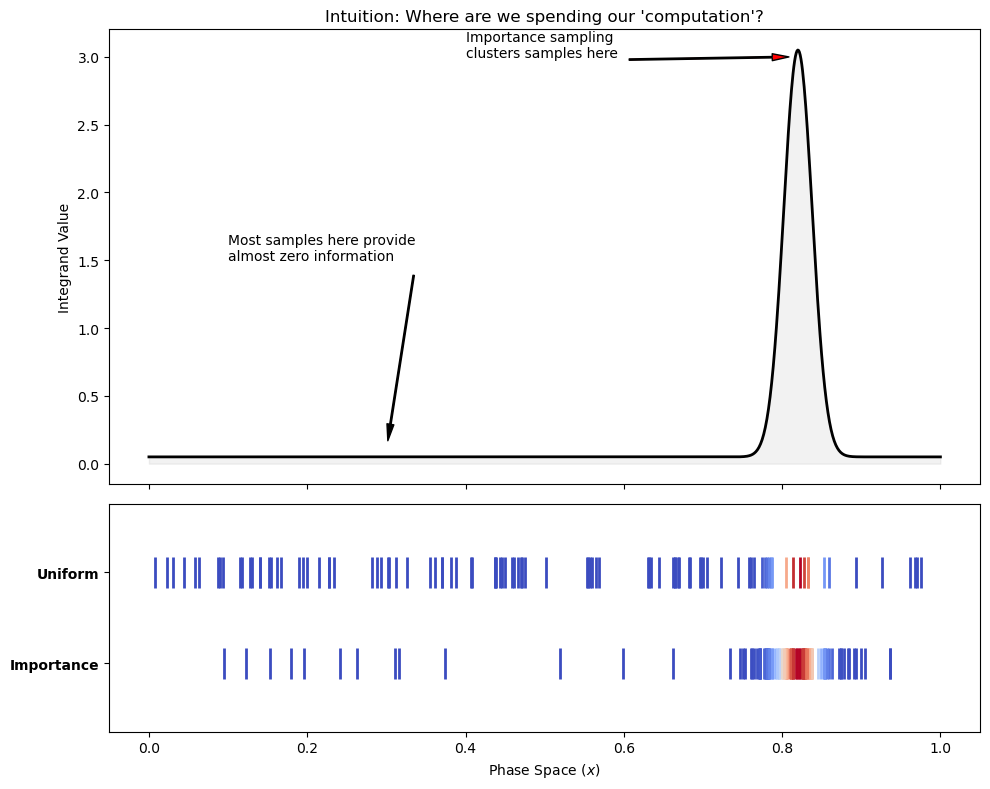

In [4]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# --- Target Function ---
x = np.linspace(0, 1, 1000)
peak_mu, peak_sigma = 0.82, 0.018
f = 0.05 + 3.0 * np.exp(-0.5 * ((x - peak_mu) / peak_sigma) ** 2)

# --- Sampling ---
n = 100
x_uni = rng.uniform(0, 1, n)
f_uni = 0.05 + 3.0 * np.exp(-0.5 * ((x_uni - peak_mu) / peak_sigma) ** 2)

# Importance: 80% around peak, 20% uniform
n_peak = int(n * 0.8)
x_imp = np.concatenate([
    rng.normal(peak_mu, 0.04, n_peak),
    rng.uniform(0, 1, n - n_peak)
])
x_imp = np.clip(x_imp, 0, 1)
f_imp = 0.05 + 3.0 * np.exp(-0.5 * ((x_imp - peak_mu) / peak_sigma) ** 2)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# Top Plot: The Function
ax1.plot(x, f, color='black', lw=2, label="Integrand $f(x)$", zorder=3)
ax1.fill_between(x, f, color='gray', alpha=0.1)
ax1.set_ylabel("Integrand Value")
ax1.set_title("Intuition: Where are we spending our 'computation'?")

# Bottom Plot: The Samples (Color-coded by f(x) value)
# High f(x) = Bright Red (High Information), Low f(x) = Pale Blue (Low Information)
cmap = plt.cm.coolwarm

ax2.scatter(x_uni, np.full_like(x_uni, 1.2), c=f_uni, cmap=cmap, 
            marker='|', s=500, linewidths=2, label="Uniform MC")
ax2.scatter(x_imp, np.full_like(x_imp, 0.8), c=f_imp, cmap=cmap, 
            marker='|', s=500, linewidths=2, label="Importance Sampling")

# Labels and Styling
ax2.set_yticks([0.8, 1.2])
ax2.set_yticklabels(["Importance", "Uniform"], fontweight='bold')
ax2.set_ylim(0.5, 1.5)
ax2.set_xlabel("Phase Space ($x$)")

# Annotate the "Information Gap"
ax1.annotate('Most samples here provide\nalmost zero information', xy=(0.3, 0.1), xytext=(0.1, 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

ax1.annotate('Importance sampling\nclusters samples here', xy=(peak_mu, 3), xytext=(0.4, 3),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()

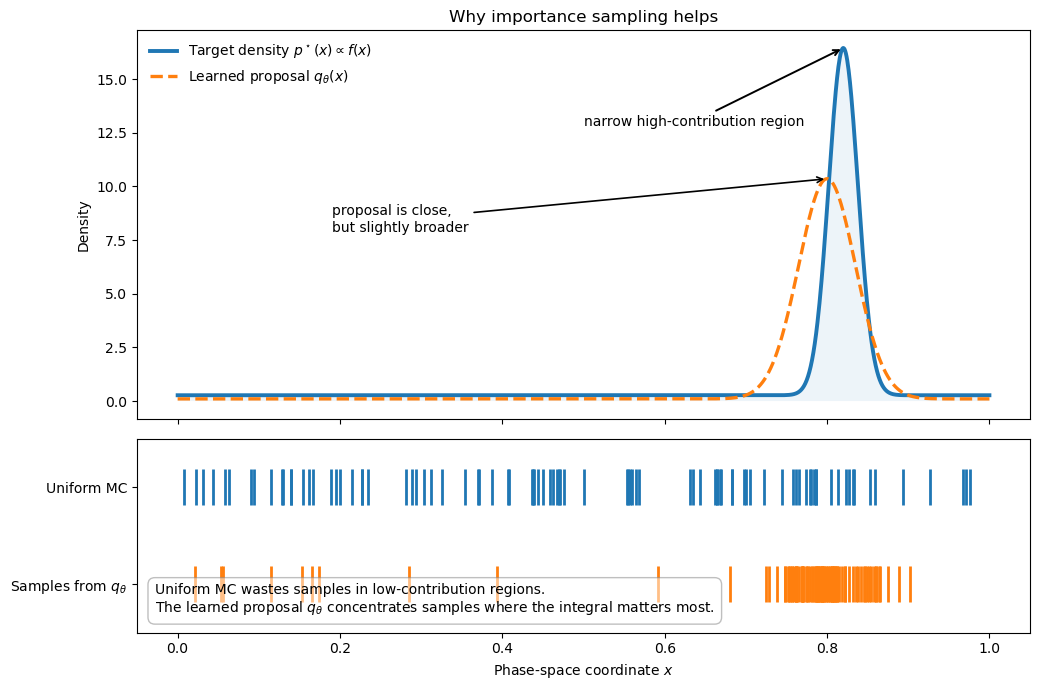

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import simpson

# -----------------------------
# Reproducibility
# -----------------------------
rng = np.random.default_rng(42)

# -----------------------------
# 1. Target / integrand shape on [0,1]
# -----------------------------
x = np.linspace(0.0, 1.0, 1200)

peak_mu = 0.82
peak_sigma = 0.018

# "Ugly" narrow-peak integrand
f_raw = 0.05 + 3.0 * np.exp(-0.5 * ((x - peak_mu) / peak_sigma) ** 2)

# Normalize only for visual comparison
f_norm = f_raw / simpson(y=f_raw, x=x)

# -----------------------------
# 2. Learned proposal q_theta(x)
# -----------------------------
# Slightly imperfect proposal: shifted mean, broader width
q_mu = 0.80
q_sigma = 0.035

def q_theta(xval):
    # Mixture proposal: narrow Gaussian + small uniform background
    return 0.90 * norm.pdf(xval, loc=q_mu, scale=q_sigma) + 0.10 * 1.0

q_curve = q_theta(x)

# -----------------------------
# 3. Sampling
# -----------------------------
n = 90

# Uniform MC samples
x_uni = rng.uniform(0.0, 1.0, n)

# Proposal samples from q_theta
# Use rejection sampling so the sampled points really live on [0,1]
mix = rng.uniform(0.0, 1.0, n)
x_flow = np.empty(n)

gauss_mask = mix < 0.90
n_gauss = gauss_mask.sum()

vals = []
while len(vals) < n_gauss:
    cand = rng.normal(loc=q_mu, scale=q_sigma, size=n_gauss)
    cand = cand[(cand >= 0.0) & (cand <= 1.0)]
    vals.extend(cand.tolist())

x_flow[gauss_mask] = np.array(vals[:n_gauss])
x_flow[~gauss_mask] = rng.uniform(0.0, 1.0, (~gauss_mask).sum())

# -----------------------------
# 4. Plot
# -----------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10.5, 7.0),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0]}
)

# ---- top panel: densities ----
ax1.plot(x, f_norm, lw=2.8, label=r"Target density $p^\star(x)\propto f(x)$")
ax1.plot(x, q_curve, lw=2.4, ls="--", label=r"Learned proposal $q_\theta(x)$")

ax1.fill_between(x, f_norm, alpha=0.08)

ax1.annotate(
    "narrow high-contribution region",
    xy=(peak_mu, f_norm.max()),
    xytext=(0.50, f_norm.max() * 0.78),
    arrowprops=dict(arrowstyle="->", lw=1.4),
)

ax1.annotate(
    "proposal is close,\nbut slightly broader",
    xy=(q_mu, q_theta(q_mu)),
    xytext=(0.19, f_norm.max() * 0.48),
    arrowprops=dict(arrowstyle="->", lw=1.2),
)

ax1.set_ylabel("Density")
ax1.set_title("Why importance sampling helps")
ax1.legend(frameon=False, loc="upper left")

# ---- bottom panel: sample locations ----
y_uniform = 1.35
y_flow = 0.65

ax2.scatter(
    x_uni,
    np.full_like(x_uni, y_uniform),
    marker="|",
    s=650,
    linewidths=2.0,
    label="Uniform MC samples",
)

ax2.scatter(
    x_flow,
    np.full_like(x_flow, y_flow),
    marker="|",
    s=650,
    linewidths=2.0,
    label=r"Samples from $q_\theta(x)$",
)

ax2.set_yticks([y_flow, y_uniform])
ax2.set_yticklabels([r"Samples from $q_\theta$", "Uniform MC"])
ax2.set_ylim(0.3, 1.7)
ax2.set_xlabel(r"Phase-space coordinate $x$")

# A short text message on the bottom panel
# ax2.text(
#     0.0, 0.10,
#     "Uniform MC may waste samples in low-contribution regions,\n"
#     "while a learned proposal places more samples where the integral matters most.",
#     transform=ax2.transAxes,
#     fontsize=10,
#     va="bottom"
# )
# Replace the old ax2.text block with this:
text_str = (
    "Uniform MC wastes samples in low-contribution regions.\n"
    "The learned proposal $q_\\theta$ concentrates samples where the integral matters most."
)

ax2.text(
    0.02, 0.08, # Slightly shifted for better margin
    text_str,
    transform=ax2.transAxes,
    fontsize=10,
    va="bottom",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.5)
)

plt.tight_layout()
plt.show()

# Optional save:
fig.savefig("importance_sampling_presentation.png", dpi=200, bbox_inches="tight")